# Notebook 05: New Baseline — EfficientNet-B0 + DenseNet121 Ensemble

This notebook follows the structure of the course preparation notebooks:
- **Notebook 02** (transfer learning → fine-tune → + augmentation)
- **Notebook 03** (evaluation metrics → TTA)

We train **two ImageNet-pretrained backbones** through all three stages, then combine them:

1. **EfficientNet-B0** — 5M params, 1280-feature head, strong compound-scaled CNN
2. **DenseNet121** — 7M params, 1024-feature head, dense connections

Final pipeline:
- Stage 1: frozen backbone, train head only (warm-up)
- Stage 2: unfreeze upper blocks, differential LR (tiny LR for backbone, larger for head)
- Stage 3: fine-tune + training-time augmentation
- **TTA** (multi-pass averaging per backbone)
- **Ensemble** (average TTA probabilities from both backbones)
- Re-tune threshold on the ensemble validation probabilities
- Generate submission CSV

**Datathon rule reminder:** ImageNet-pretrained only — no medically-pretrained weights.

---
## Step 1: Imports

In [1]:
import copy                                         # deep-copy best model state
import random                                       # Python RNG seeding
import time                                         # epoch timing + timestamp for submissions
from pathlib import Path                            # filesystem paths

import matplotlib.pyplot as plt                     # plots
import numpy as np                                  # numerical arrays
import pandas as pd                                 # labels CSV + submission CSV
import torch                                        # PyTorch core
import torch.nn as nn                               # loss + layers
import torch.nn.functional as F                     # F.interpolate for multi-scale TTA
import torch.optim as optim                         # AdamW / Adam
import torchvision.transforms as T                  # image transforms
from PIL import Image                               # read PNGs
from sklearn.metrics import roc_auc_score, roc_curve  # AUROC + ROC plot
from sklearn.model_selection import train_test_split  # stratified 80/20 split
from torch.utils.data import DataLoader, Dataset   # data loading
from torchvision.models import (                    # both backbones, ImageNet-only weights
    DenseNet121_Weights,
    EfficientNet_B0_Weights,
    densenet121,
    efficientnet_b0,
)
from tqdm.auto import tqdm                          # progress bars

print("Imports OK")

Imports OK


/Users/jasonsmith/Desktop/medical-cv-hackathon/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 2: Reproducibility and device

In [2]:
SEED = 42                                           # single seed everywhere for reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():               # Apple Silicon
    device = torch.device("mps")
elif torch.cuda.is_available():                     # NVIDIA
    device = torch.device("cuda")
else:                                               # fallback
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Step 3: Configuration

All knobs in one place. Lower `IMG_SIZE` if you want faster iteration.

In [3]:
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TRAIN_CSV = REPO / "data" / "train_val" / "train_val.csv"
TRAIN_IMG_DIR = REPO / "data" / "train_val" / "images"
TEST_IMG_DIR = REPO / "data" / "test_images"
PRED_DIR = REPO / "outputs" / "predictions"
CKPT_DIR = REPO / "outputs" / "checkpoints"
PRED_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = 512                                      # 512 = good size/speed trade-off on MPS
BATCH_SIZE = 16                                     # drop to 8 if memory is tight
NUM_WORKERS = 0                                     # MPS: keep 0
VAL_FRAC = 0.2                                      # 80/20 stratified train/val

# Training epochs per stage (can reduce for faster debugging)
EPOCHS_FROZEN = 5
EPOCHS_FT = 5
EPOCHS_AUG = 10

# ImageNet normalisation (both backbones were pretrained on ImageNet)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# TTA: number of passes per model at inference.
# Pass 0 = base, others = base+hflip at multiple scales.
TTA_SCALES = [IMG_SIZE, IMG_SIZE + 64, IMG_SIZE + 128]  # multi-scale averaging

print(f"Train CSV : {TRAIN_CSV}")
print(f"IMG_SIZE  : {IMG_SIZE}")
print(f"TTA scales: {TTA_SCALES} (× {{orig, hflip}} = {2*len(TTA_SCALES)} passes)")

Train CSV : /Users/jasonsmith/Desktop/medical-cv-hackathon/data/train_val/train_val.csv
IMG_SIZE  : 512
TTA scales: [512, 576, 640] (× {orig, hflip} = 6 passes)


## Step 4: Load labels and check class balance

In [4]:
df = pd.read_csv(TRAIN_CSV)
df = df.rename(columns={
    "Image Index": "image_file",
    "Patient Age": "age",
    "Patient Sex": "sex",
    "Finding Labels": "finding",
})
df["label"] = (df["finding"] == "Cardiomegaly").astype(int)

print(df.head())
print("\nFinding counts:")
print(df["finding"].value_counts())
print(f"\nPositive rate: {df['label'].mean():.3f}")
print(f"Total        : {len(df)}")

       image_file  age sex       finding  label
0  IMG_000838.png   65   F  Cardiomegaly      1
1  IMG_000239.png   76   F  Cardiomegaly      1
2  IMG_000217.png   61   M    No Finding      0
3  IMG_001193.png   52   F    No Finding      0
4  IMG_001097.png   35   F    No Finding      0

Finding counts:
finding
No Finding      858
Cardiomegaly    720
Name: count, dtype: int64

Positive rate: 0.456
Total        : 1578


## Step 5: Dataset class

Same as the other baselines — converts grayscale / RGBA PNGs to 3-channel RGB before applying transforms.

In [5]:
class CardiomegalyDataset(Dataset):
    """Reads chest X-rays from a folder of PNGs + a DataFrame with labels."""

    def __init__(self, df, img_dir, transform=None, return_label=True):
        self.df = df.reset_index(drop=True)
        self.img_dir = Path(img_dir)
        self.transform = transform
        self.return_label = return_label

    def __len__(self):
        return len(self.df)

    def _load_image(self, fname):
        img = Image.open(self.img_dir / fname)
        if img.mode != "RGB":                                # L or RGBA → RGB
            img = img.convert("RGB")
        return img

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self._load_image(row["image_file"])
        if self.transform is not None:
            img = self.transform(img)
        if not self.return_label:
            return img, row["image_file"]
        return img, torch.tensor(row["label"], dtype=torch.float32)

## Step 6: Stratified 80/20 split

In [6]:
train_df, val_df = train_test_split(
    df, test_size=VAL_FRAC, stratify=df["label"], random_state=SEED
)
print(f"Train: {len(train_df)}  (pos rate {train_df['label'].mean():.3f})")
print(f"Val  : {len(val_df)}  (pos rate {val_df['label'].mean():.3f})")

Train: 1262  (pos rate 0.456)
Val  : 316  (pos rate 0.456)


## Step 7: Transforms and DataLoaders

Two training transforms — `train_tf` (no augmentation, used by Stages 1 and 2) and `train_tf_aug` (used by Stage 3). Validation stays deterministic.

In [7]:
def build_transform(img_size, augment=False):
    ops = [T.Resize((img_size, img_size))]
    if augment:
        ops += [
            T.RandomHorizontalFlip(p=0.5),              # safe for cardiomegaly (central heart shadow)
            T.RandomRotation(degrees=5),                # small rotation only
            T.ColorJitter(brightness=0.1, contrast=0.1),  # mild intensity jitter
        ]
    ops += [
        T.ToTensor(),
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ]
    return T.Compose(ops)

train_tf = build_transform(IMG_SIZE, augment=False)
val_tf = build_transform(IMG_SIZE, augment=False)
train_tf_aug = build_transform(IMG_SIZE, augment=True)

train_ds = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf)
train_ds_aug = CardiomegalyDataset(train_df, TRAIN_IMG_DIR, transform=train_tf_aug)
val_ds = CardiomegalyDataset(val_df, TRAIN_IMG_DIR, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)} (same for aug loader)")
print(f"Val   batches: {len(val_loader)}")

Train batches: 79 (same for aug loader)
Val   batches: 20


## Step 8: Visualize a training batch (with augmentation)

Quick sanity check that augmentations look reasonable and labels line up.

Batch shape: torch.Size([16, 3, 512, 512])  dtype: torch.float32


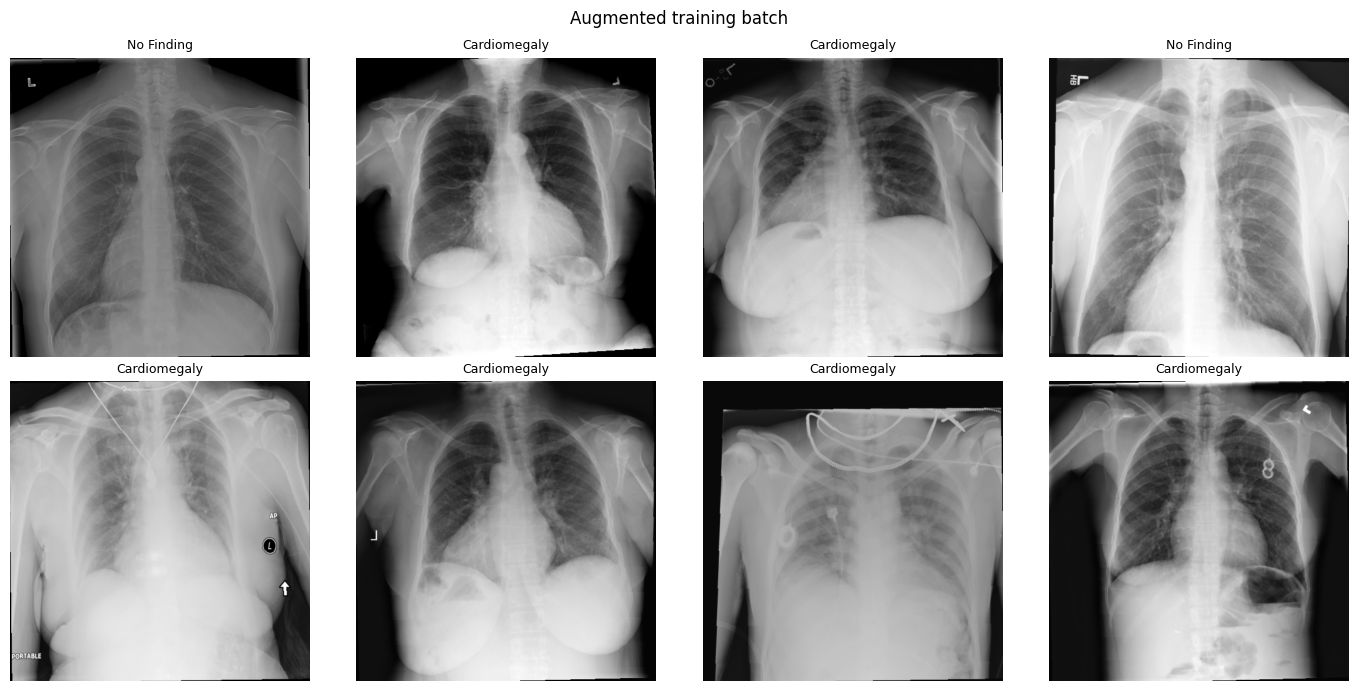

In [8]:
def denorm(x):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (x * std + mean).clamp(0, 1)

imgs, labels = next(iter(train_loader_aug))
print(f"Batch shape: {imgs.shape}  dtype: {imgs.dtype}")

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, img, lbl in zip(axes.flat, imgs, labels):
    ax.imshow(denorm(img).permute(1, 2, 0).numpy())
    ax.set_title("Cardiomegaly" if lbl.item() else "No Finding", fontsize=9)
    ax.axis("off")
plt.suptitle("Augmented training batch", fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 9: Metrics helpers

The datathon scores `0.5·AUROC + 0.25·sens + 0.25·spec` — we compute and track all three.

In [9]:
def sens_spec(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    pred = (y_prob >= threshold).astype(int)
    tp = int(((pred == 1) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    return sens, spec

def datathon_score(auroc, sens, spec):
    return 0.5 * auroc + 0.25 * sens + 0.25 * spec

def best_threshold_youden(y_true, y_prob):
    """Threshold maximising Youden's J (sens + spec - 1) — continuous candidate set from ROC curve."""
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    j = tpr - fpr
    return float(thr[np.argmax(j)])

def best_threshold_score(y_true, y_prob):
    """Threshold maximising the datathon score via grid search."""
    best_t, best_s = 0.5, -1.0
    for t in np.linspace(0.05, 0.95, 181):
        sens, spec = sens_spec(y_true, y_prob, threshold=t)
        # AUROC doesn't depend on threshold, so use it as a constant add-on
        s = datathon_score(roc_auc_score(y_true, y_prob), sens, spec)
        if s > best_s:
            best_s, best_t = s, float(t)
    return best_t, best_s

## Step 10: Train / eval loops (shared across both backbones)

In [10]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    ys, ps = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        logits = model(imgs).squeeze(1)
        probs = torch.sigmoid(logits).detach().cpu().numpy()
        ys.extend(labels.numpy().tolist())
        ps.extend(probs.tolist())
    ys, ps = np.array(ys), np.array(ps)
    auroc = roc_auc_score(ys, ps)
    sens, spec = sens_spec(ys, ps, threshold=0.5)
    return {"auroc": auroc, "sens": sens, "spec": spec, "y": ys, "p": ps}

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0.0
    pbar = tqdm(loader, leave=False)
    for imgs, labels in pbar:
        imgs = imgs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total += loss.item()
        pbar.set_description(f"loss {loss.item():.3f}")
    return total / len(loader)

def train(model, tr_loader, vl_loader, optimizer, epochs, device, tag="model"):
    criterion = nn.BCEWithLogitsLoss()
    best = {"auroc": -1.0, "state": None, "epoch": 0}
    history = []
    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss = train_one_epoch(model, tr_loader, optimizer, criterion, device)
        val = evaluate(model, vl_loader, device)
        dt = time.time() - t0
        score = datathon_score(val["auroc"], val["sens"], val["spec"])
        history.append({"epoch": epoch, "loss": tr_loss,
                        **{k: val[k] for k in ("auroc", "sens", "spec")}, "score": score})
        star = ""
        if val["auroc"] > best["auroc"]:
            best = {"auroc": val["auroc"], "state": copy.deepcopy(model.state_dict()), "epoch": epoch}
            star = " ★"
            torch.save(model.state_dict(), CKPT_DIR / f"{tag}_best.pt")
        print(
            f"[{tag}] ep {epoch:02d}/{epochs}  loss {tr_loss:.4f}  "
            f"AUROC {val['auroc']:.4f}  sens {val['sens']:.3f}  spec {val['spec']:.3f}  "
            f"score {score:.4f}  ({dt:.1f}s){star}"
        )
    model.load_state_dict(best["state"])
    return model, history, best

---
# Part 1 — EfficientNet-B0

Three stages: frozen → fine-tune → + augmentation. Same progression as the professor's notebook 02.

## Stage 1: Frozen EfficientNet-B0

All pretrained layers frozen, only the 1280→1 head trains. Baseline warm-up.

In [11]:
def build_efnet_frozen():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, 1))
    return model

def build_efnet_finetune():
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    # EfficientNet-B0 `features` has 9 blocks (0-8); unfreeze last 3 (blocks 6-8)
    for p in model.features[6:].parameters():
        p.requires_grad = True
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1280, 1))
    return model

efnet_frozen = build_efnet_frozen().to(device)
n_tr = sum(p.numel() for p in efnet_frozen.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in efnet_frozen.parameters())
print(f"EfficientNet-B0 frozen — trainable: {n_tr:,} / {n_tot:,} ({100*n_tr/n_tot:.2f}%)")

opt = optim.Adam(efnet_frozen.classifier.parameters(), lr=1e-3)
efnet_frozen, hist_ef1, best_ef1 = train(
    efnet_frozen, train_loader, val_loader, opt,
    epochs=EPOCHS_FROZEN, device=device, tag="efnet_stage1_frozen"
)

EfficientNet-B0 frozen — trainable: 1,281 / 4,008,829 (0.03%)


[efnet_stage1_frozen] ep 01/5  loss 0.6447  AUROC 0.7360  sens 0.521  spec 0.831  score 0.7061  (40.9s) ★


[efnet_stage1_frozen] ep 02/5  loss 0.6021  AUROC 0.7498  sens 0.500  spec 0.866  score 0.7164  (41.5s) ★


[efnet_stage1_frozen] ep 03/5  loss 0.5922  AUROC 0.7612  sens 0.597  spec 0.808  score 0.7319  (39.7s) ★


[efnet_stage1_frozen] ep 04/5  loss 0.5763  AUROC 0.7720  sens 0.479  spec 0.866  score 0.7224  (39.2s) ★


[efnet_stage1_frozen] ep 05/5  loss 0.5736  AUROC 0.7737  sens 0.465  spec 0.855  score 0.7169  (40.7s) ★


## Stage 2: Fine-tune upper blocks

Unfreeze `features[6:]`. Differential LR — 1e-5 for pretrained weights, 1e-4 for the head.

In [12]:
efnet_ft = build_efnet_finetune().to(device)
n_tr = sum(p.numel() for p in efnet_ft.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in efnet_ft.parameters())
print(f"EfficientNet-B0 fine-tune — trainable: {n_tr:,} / {n_tot:,} ({100*n_tr/n_tot:.2f}%)")

opt = optim.AdamW([
    {"params": efnet_ft.features[6:].parameters(), "lr": 1e-5},
    {"params": efnet_ft.classifier.parameters(),   "lr": 1e-4},
])
efnet_ft, hist_ef2, best_ef2 = train(
    efnet_ft, train_loader, val_loader, opt,
    epochs=EPOCHS_FT, device=device, tag="efnet_stage2_finetune"
)

EfficientNet-B0 fine-tune — trainable: 3,157,021 / 4,008,829 (78.75%)


[efnet_stage2_finetune] ep 01/5  loss 0.6755  AUROC 0.7740  sens 0.444  spec 0.913  score 0.7263  (53.1s) ★


[efnet_stage2_finetune] ep 02/5  loss 0.6394  AUROC 0.7733  sens 0.597  spec 0.843  score 0.7467  (46.6s)


[efnet_stage2_finetune] ep 03/5  loss 0.6065  AUROC 0.7879  sens 0.604  spec 0.837  score 0.7543  (47.7s) ★


[efnet_stage2_finetune] ep 04/5  loss 0.5799  AUROC 0.7996  sens 0.646  spec 0.831  score 0.7691  (46.7s) ★


[efnet_stage2_finetune] ep 05/5  loss 0.5467  AUROC 0.8127  sens 0.681  spec 0.791  score 0.7741  (46.4s) ★


## Stage 3: Fine-tune + augmentation

Same architecture as Stage 2, but the train loader uses `train_tf_aug` (hflip + rotation + jitter).

In [13]:
efnet_aug = build_efnet_finetune().to(device)
opt = optim.AdamW([
    {"params": efnet_aug.features[6:].parameters(), "lr": 1e-5},
    {"params": efnet_aug.classifier.parameters(),   "lr": 1e-4},
])
efnet_aug, hist_ef3, best_ef3 = train(
    efnet_aug, train_loader_aug, val_loader, opt,
    epochs=EPOCHS_AUG, device=device, tag="efnet_stage3_aug"
)

[efnet_stage3_aug] ep 01/10  loss 0.6813  AUROC 0.7086  sens 0.062  spec 0.983  score 0.6156  (52.5s) ★


[efnet_stage3_aug] ep 02/10  loss 0.6513  AUROC 0.7437  sens 0.438  spec 0.878  score 0.7007  (50.1s) ★


[efnet_stage3_aug] ep 03/10  loss 0.6253  AUROC 0.7699  sens 0.389  spec 0.907  score 0.7089  (51.1s) ★


[efnet_stage3_aug] ep 04/10  loss 0.6051  AUROC 0.7836  sens 0.576  spec 0.855  score 0.7495  (48.1s) ★


[efnet_stage3_aug] ep 05/10  loss 0.5792  AUROC 0.7955  sens 0.639  spec 0.855  score 0.7711  (47.9s) ★


[efnet_stage3_aug] ep 06/10  loss 0.5558  AUROC 0.8123  sens 0.653  spec 0.826  score 0.7757  (50.8s) ★


[efnet_stage3_aug] ep 07/10  loss 0.5393  AUROC 0.8312  sens 0.667  spec 0.855  score 0.7959  (51.0s) ★


[efnet_stage3_aug] ep 08/10  loss 0.5210  AUROC 0.8396  sens 0.708  spec 0.826  score 0.8033  (50.6s) ★


[efnet_stage3_aug] ep 09/10  loss 0.5119  AUROC 0.8486  sens 0.715  spec 0.808  score 0.8052  (49.4s) ★


[efnet_stage3_aug] ep 10/10  loss 0.4884  AUROC 0.8576  sens 0.729  spec 0.814  score 0.8146  (49.5s) ★


---
# Part 2 — DenseNet121

Same three-stage recipe. Different architecture → different learned features → useful diversity when we ensemble.

## Stage 1: Frozen DenseNet121

All weights frozen except a new 1024→1 binary head.

In [14]:
def build_dnet_frozen():
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1024, 1))
    return model

def build_dnet_finetune():
    model = densenet121(weights=DenseNet121_Weights.IMAGENET1K_V1)
    for p in model.parameters():
        p.requires_grad = False
    # Unfreeze the last dense block and final batch-norm
    for p in model.features.denseblock4.parameters():
        p.requires_grad = True
    for p in model.features.norm5.parameters():
        p.requires_grad = True
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(1024, 1))
    return model

dnet_frozen = build_dnet_frozen().to(device)
n_tr = sum(p.numel() for p in dnet_frozen.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in dnet_frozen.parameters())
print(f"DenseNet121 frozen — trainable: {n_tr:,} / {n_tot:,} ({100*n_tr/n_tot:.2f}%)")

opt = optim.Adam(dnet_frozen.classifier.parameters(), lr=1e-3)
dnet_frozen, hist_dn1, best_dn1 = train(
    dnet_frozen, train_loader, val_loader, opt,
    epochs=EPOCHS_FROZEN, device=device, tag="dnet_stage1_frozen"
)

DenseNet121 frozen — trainable: 1,025 / 6,954,881 (0.01%)


[dnet_stage1_frozen] ep 01/5  loss 0.7036  AUROC 0.7455  sens 0.681  spec 0.738  score 0.7275  (69.1s) ★


[dnet_stage1_frozen] ep 02/5  loss 0.6453  AUROC 0.7659  sens 0.757  spec 0.651  score 0.7350  (64.8s) ★


[dnet_stage1_frozen] ep 03/5  loss 0.6434  AUROC 0.7720  sens 0.424  spec 0.890  score 0.7143  (65.0s) ★


[dnet_stage1_frozen] ep 04/5  loss 0.6209  AUROC 0.7778  sens 0.597  spec 0.820  score 0.7432  (64.5s) ★


[dnet_stage1_frozen] ep 05/5  loss 0.6178  AUROC 0.7800  sens 0.562  spec 0.849  score 0.7429  (64.9s) ★


## Stage 2: Fine-tune DenseNet121

Unfreeze `denseblock4` + `norm5` with the same differential-LR recipe.

In [15]:
dnet_ft = build_dnet_finetune().to(device)
n_tr = sum(p.numel() for p in dnet_ft.parameters() if p.requires_grad)
n_tot = sum(p.numel() for p in dnet_ft.parameters())
print(f"DenseNet121 fine-tune — trainable: {n_tr:,} / {n_tot:,} ({100*n_tr/n_tot:.2f}%)")

unfrozen_dnet = list(dnet_ft.features.denseblock4.parameters()) + list(dnet_ft.features.norm5.parameters())
opt = optim.AdamW([
    {"params": unfrozen_dnet,                      "lr": 1e-5},
    {"params": dnet_ft.classifier.parameters(),    "lr": 1e-4},
])
dnet_ft, hist_dn2, best_dn2 = train(
    dnet_ft, train_loader, val_loader, opt,
    epochs=EPOCHS_FT, device=device, tag="dnet_stage2_finetune"
)

DenseNet121 fine-tune — trainable: 2,161,153 / 6,954,881 (31.07%)


[dnet_stage2_finetune] ep 01/5  loss 0.6906  AUROC 0.7117  sens 0.493  spec 0.849  score 0.6913  (70.3s) ★


[dnet_stage2_finetune] ep 02/5  loss 0.6432  AUROC 0.7451  sens 0.535  spec 0.831  score 0.7141  (69.0s) ★


[dnet_stage2_finetune] ep 03/5  loss 0.6129  AUROC 0.7606  sens 0.618  spec 0.791  score 0.7325  (67.2s) ★


[dnet_stage2_finetune] ep 04/5  loss 0.5890  AUROC 0.7726  sens 0.604  spec 0.808  score 0.7394  (67.6s) ★


[dnet_stage2_finetune] ep 05/5  loss 0.5806  AUROC 0.7789  sens 0.542  spec 0.878  score 0.7443  (67.5s) ★


## Stage 3: Fine-tune DenseNet121 + augmentation

In [16]:
dnet_aug = build_dnet_finetune().to(device)
unfrozen_dnet = list(dnet_aug.features.denseblock4.parameters()) + list(dnet_aug.features.norm5.parameters())
opt = optim.AdamW([
    {"params": unfrozen_dnet,                      "lr": 1e-5},
    {"params": dnet_aug.classifier.parameters(),   "lr": 1e-4},
])
dnet_aug, hist_dn3, best_dn3 = train(
    dnet_aug, train_loader_aug, val_loader, opt,
    epochs=EPOCHS_AUG, device=device, tag="dnet_stage3_aug"
)

[dnet_stage3_aug] ep 01/10  loss 0.6895  AUROC 0.7169  sens 0.222  spec 0.942  score 0.6494  (71.7s) ★


[dnet_stage3_aug] ep 02/10  loss 0.6512  AUROC 0.7553  sens 0.625  spec 0.756  score 0.7228  (72.6s) ★


[dnet_stage3_aug] ep 03/10  loss 0.6196  AUROC 0.7703  sens 0.514  spec 0.866  score 0.7302  (71.1s) ★


[dnet_stage3_aug] ep 04/10  loss 0.6104  AUROC 0.7816  sens 0.604  spec 0.826  score 0.7482  (71.4s) ★


[dnet_stage3_aug] ep 05/10  loss 0.6000  AUROC 0.7876  sens 0.674  spec 0.785  score 0.7584  (70.8s) ★


[dnet_stage3_aug] ep 06/10  loss 0.5886  AUROC 0.7959  sens 0.646  spec 0.826  score 0.7658  (71.9s) ★


[dnet_stage3_aug] ep 07/10  loss 0.5756  AUROC 0.7997  sens 0.604  spec 0.849  score 0.7631  (71.8s) ★


[dnet_stage3_aug] ep 08/10  loss 0.5662  AUROC 0.8098  sens 0.632  spec 0.843  score 0.7736  (72.4s) ★


[dnet_stage3_aug] ep 09/10  loss 0.5542  AUROC 0.8150  sens 0.583  spec 0.860  score 0.7685  (71.6s) ★


[dnet_stage3_aug] ep 10/10  loss 0.5416  AUROC 0.8190  sens 0.611  spec 0.866  score 0.7788  (76.3s) ★


---
# Part 3 — Compare stages and pick the best model per backbone

Matching the evaluation approach from the professor's notebook 03: AUROC, ROC curves, per-threshold sens/spec, and Youden's J threshold tuning.

In [17]:
stage_models = {
    "efnet_stage1_frozen":   efnet_frozen,
    "efnet_stage2_finetune": efnet_ft,
    "efnet_stage3_aug":      efnet_aug,
    "dnet_stage1_frozen":    dnet_frozen,
    "dnet_stage2_finetune":  dnet_ft,
    "dnet_stage3_aug":       dnet_aug,
}

rows = []
probs_by_model = {}
for name, m in stage_models.items():
    v = evaluate(m, val_loader, device)
    probs_by_model[name] = (v["y"], v["p"])
    thr_y = best_threshold_youden(v["y"], v["p"])
    sens_t, spec_t = sens_spec(v["y"], v["p"], threshold=thr_y)
    rows.append({
        "model": name,
        "auroc": v["auroc"],
        "thr": thr_y,
        "sens": sens_t,
        "spec": spec_t,
        "score": datathon_score(v["auroc"], sens_t, spec_t),
    })

summary = pd.DataFrame(rows).sort_values("score", ascending=False)
print(summary.to_string(index=False))

                model    auroc      thr     sens     spec    score
     efnet_stage3_aug 0.857558 0.571823 0.687500 0.889535 0.823038
efnet_stage2_finetune 0.812661 0.453494 0.770833 0.750000 0.786539
      dnet_stage3_aug 0.818960 0.444730 0.715278 0.790698 0.785974
   dnet_stage1_frozen 0.780039 0.422883 0.722222 0.755814 0.759528
 dnet_stage2_finetune 0.778868 0.408799 0.722222 0.738372 0.754583
  efnet_stage1_frozen 0.773740 0.335876 0.805556 0.651163 0.751050


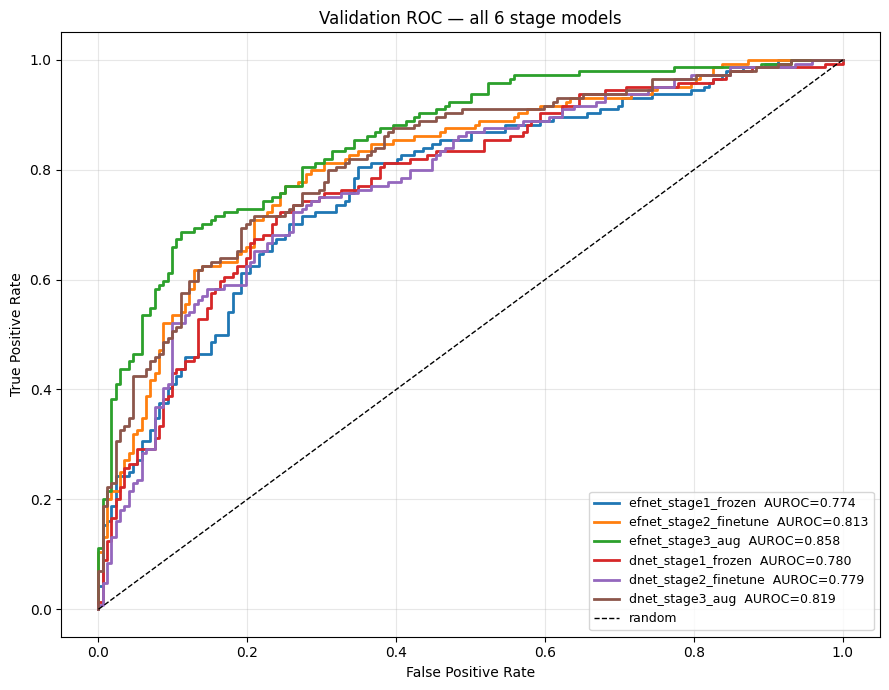

In [18]:
# ROC plot — all six stage models
fig, ax = plt.subplots(figsize=(9, 7))
for name, (y, p) in probs_by_model.items():
    fpr, tpr, _ = roc_curve(y, p)
    auc_val = roc_auc_score(y, p)
    ax.plot(fpr, tpr, lw=2, label=f"{name}  AUROC={auc_val:.3f}")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC — all 6 stage models")
ax.legend(loc="lower right", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Pick the best Stage-3 (augmented) model from each backbone for TTA + ensembling
best_efnet = efnet_aug
best_dnet = dnet_aug
print("Selected for TTA + ensemble:")
print("  EfficientNet-B0 → efnet_stage3_aug")
print("  DenseNet121     → dnet_stage3_aug")

Selected for TTA + ensemble:
  EfficientNet-B0 → efnet_stage3_aug
  DenseNet121     → dnet_stage3_aug


---
# Part 4 — Test-Time Augmentation (TTA)

At inference we pass the image through the model several times with different *deterministic* views and average the sigmoid probabilities. Views used here:

- Multi-scale: resample the input tensor to several sizes via `F.interpolate`
- Horizontal flip: a safe augmentation for cardiomegaly (heart shadow is roughly central)

Total = `len(TTA_SCALES) × 2` passes per model. Averaging smooths out noise from any single view.

In [20]:
@torch.no_grad()
def predict_probs_tta(model, loader, device, scales=TTA_SCALES):
    """Average sigmoid probs across multi-scale × {orig, hflip} passes."""
    model.eval()
    all_probs, all_ys = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        probs_accum = torch.zeros(imgs.size(0), device=device)
        passes = 0
        for scale in scales:
            # Resize to this scale. If scale == current size, skip the interp for speed.
            if scale == imgs.size(-1):
                x = imgs
            else:
                x = F.interpolate(imgs, size=(scale, scale), mode="bilinear", align_corners=False)
            # Original
            probs_accum += torch.sigmoid(model(x).squeeze(1))
            passes += 1
            # Horizontal flip
            probs_accum += torch.sigmoid(model(torch.flip(x, dims=[3])).squeeze(1))
            passes += 1
        probs_accum /= passes
        all_probs.extend(probs_accum.cpu().numpy().tolist())
        all_ys.extend(labels.numpy().tolist())
    return np.array(all_ys), np.array(all_probs)

In [21]:
# Run TTA for each backbone's best (Stage-3) model and compare to single-pass
print("Running TTA on EfficientNet-B0 (stage3_aug)...")
y_val, efnet_probs_tta = predict_probs_tta(best_efnet, val_loader, device)
efnet_auc_single = roc_auc_score(*probs_by_model["efnet_stage3_aug"])
efnet_auc_tta = roc_auc_score(y_val, efnet_probs_tta)
print(f"  single-pass AUROC: {efnet_auc_single:.4f}")
print(f"  TTA AUROC       : {efnet_auc_tta:.4f}  (Δ {efnet_auc_tta - efnet_auc_single:+.4f})")

print("\nRunning TTA on DenseNet121 (stage3_aug)...")
_, dnet_probs_tta = predict_probs_tta(best_dnet, val_loader, device)
dnet_auc_single = roc_auc_score(*probs_by_model["dnet_stage3_aug"])
dnet_auc_tta = roc_auc_score(y_val, dnet_probs_tta)
print(f"  single-pass AUROC: {dnet_auc_single:.4f}")
print(f"  TTA AUROC       : {dnet_auc_tta:.4f}  (Δ {dnet_auc_tta - dnet_auc_single:+.4f})")

Running TTA on EfficientNet-B0 (stage3_aug)...
  single-pass AUROC: 0.8576
  TTA AUROC       : 0.8546  (Δ -0.0029)

Running TTA on DenseNet121 (stage3_aug)...
  single-pass AUROC: 0.8190
  TTA AUROC       : 0.8156  (Δ -0.0034)


---
# Part 5 — Ensemble both backbones

Average the TTA probabilities from the two backbones. Because EfficientNet-B0 and DenseNet121 have different inductive biases, their errors are partly uncorrelated — the mean is usually stronger than either model alone.

In [22]:
# Simple mean ensemble of TTA probs
ens_probs = (efnet_probs_tta + dnet_probs_tta) / 2.0
ens_auc = roc_auc_score(y_val, ens_probs)

# Pick the threshold that maximises the datathon score on validation
ens_thr, ens_best_score = best_threshold_score(y_val, ens_probs)
ens_sens, ens_spec = sens_spec(y_val, ens_probs, threshold=ens_thr)

print("=" * 55)
print("  Ensemble validation results")
print("=" * 55)
print(f"  EfficientNet-B0 TTA AUROC : {efnet_auc_tta:.4f}")
print(f"  DenseNet121     TTA AUROC : {dnet_auc_tta:.4f}")
print(f"  Ensemble        TTA AUROC : {ens_auc:.4f}")
print("  " + "-" * 45)
print(f"  Best threshold (grid)     : {ens_thr:.3f}")
print(f"  Sensitivity               : {ens_sens:.3f}")
print(f"  Specificity               : {ens_spec:.3f}")
print(f"  Datathon score            : {ens_best_score:.4f}")
print("=" * 55)

  Ensemble validation results
  EfficientNet-B0 TTA AUROC : 0.8546
  DenseNet121     TTA AUROC : 0.8156
  Ensemble        TTA AUROC : 0.8409
  ---------------------------------------------
  Best threshold (grid)     : 0.455
  Sensitivity               : 0.771
  Specificity               : 0.750
  Datathon score            : 0.8007


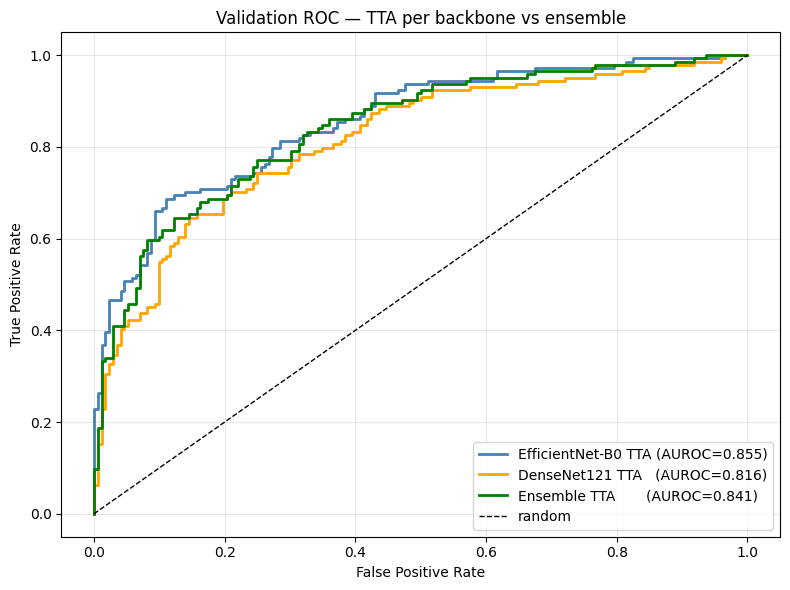

In [23]:
# ROC plot: each backbone's TTA curve + ensemble TTA curve
fig, ax = plt.subplots(figsize=(8, 6))
for name, probs, color in [
    (f"EfficientNet-B0 TTA (AUROC={efnet_auc_tta:.3f})", efnet_probs_tta, "steelblue"),
    (f"DenseNet121 TTA   (AUROC={dnet_auc_tta:.3f})",   dnet_probs_tta,   "orange"),
    (f"Ensemble TTA       (AUROC={ens_auc:.3f})",       ens_probs,        "green"),
]:
    fpr, tpr, _ = roc_curve(y_val, probs)
    ax.plot(fpr, tpr, lw=2, color=color, label=name)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="random")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Validation ROC — TTA per backbone vs ensemble")
ax.legend(loc="lower right", fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
# Part 6 — Generate submission CSV

Same TTA + ensemble pipeline applied to the 176 test images. Output columns: `image_file`, `prob`, `pred`.

In [24]:
@torch.no_grad()
def predict_probs_tta_test(model, loader, device, scales=TTA_SCALES):
    """Test-set TTA — no labels returned, image filenames instead."""
    model.eval()
    all_probs, all_names = [], []
    for imgs, names in loader:
        imgs = imgs.to(device)
        probs_accum = torch.zeros(imgs.size(0), device=device)
        passes = 0
        for scale in scales:
            x = imgs if scale == imgs.size(-1) else F.interpolate(
                imgs, size=(scale, scale), mode="bilinear", align_corners=False
            )
            probs_accum += torch.sigmoid(model(x).squeeze(1))
            passes += 1
            probs_accum += torch.sigmoid(model(torch.flip(x, dims=[3])).squeeze(1))
            passes += 1
        probs_accum /= passes
        all_probs.extend(probs_accum.cpu().numpy().tolist())
        all_names.extend(names)
    return all_names, np.array(all_probs)

# Build the test loader
test_files = sorted(p.name for p in TEST_IMG_DIR.iterdir() if p.suffix.lower() == ".png")
print(f"Test images: {len(test_files)}")
test_df = pd.DataFrame({"image_file": test_files, "label": 0})
test_tf = build_transform(IMG_SIZE, augment=False)
test_ds = CardiomegalyDataset(test_df, TEST_IMG_DIR, transform=test_tf, return_label=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

Test images: 176


In [25]:
# Run TTA on the test set for each backbone, then ensemble
print("EfficientNet-B0 test-time TTA...")
names_ef, efnet_test_probs = predict_probs_tta_test(best_efnet, test_loader, device)

print("DenseNet121 test-time TTA...")
names_dn, dnet_test_probs = predict_probs_tta_test(best_dnet, test_loader, device)

# Sanity check: same filename order from both loaders (shuffle=False)
assert names_ef == names_dn, "Test filename order mismatch between the two TTA passes"

# Ensemble
test_ens_probs = (efnet_test_probs + dnet_test_probs) / 2.0

sub = pd.DataFrame({
    "image_file": names_ef,
    "prob": test_ens_probs,
})
sub["pred"] = (sub["prob"] >= ens_thr).astype(int)
sub = sub.sort_values("image_file").reset_index(drop=True)

stamp = time.strftime("%Y%m%d_%H%M")
out_path = PRED_DIR / f"submission_effnet_densenet_ensemble_TTA_{stamp}.csv"
sub.to_csv(out_path, index=False)

print(f"\nWrote {out_path}")
print(sub.head())
print(f"\nPositive rate in submission: {sub['pred'].mean():.3f}")

EfficientNet-B0 test-time TTA...
DenseNet121 test-time TTA...

Wrote /Users/jasonsmith/Desktop/medical-cv-hackathon/outputs/predictions/submission_effnet_densenet_ensemble_TTA_20260421_1153.csv
       image_file      prob  pred
0  IMG_000018.png  0.700795     1
1  IMG_000021.png  0.142069     0
2  IMG_000039.png  0.538250     1
3  IMG_000044.png  0.380565     0
4  IMG_000047.png  0.454303     0

Positive rate in submission: 0.443


---
## Summary

| Step | What it does |
|---|---|
| Stages 1–3 (×2 backbones) | Frozen → fine-tune → fine-tune+aug, matching notebook 02's recipe |
| Threshold tuning | Grid search on datathon score, matching notebook 03 |
| TTA | Multi-scale × hflip averaging per backbone, matching notebook 03's TTA spirit |
| Ensemble | Mean of TTA probs from EfficientNet-B0 and DenseNet121 |
| Submission | CSV with `image_file`, `prob`, `pred` using the ensemble-tuned threshold |

**Ideas to try next:**
- Add ResNet18 as a third backbone for a 3-model ensemble
- K-fold CV for a lower-variance threshold estimate
- Weighted ensemble (weight each backbone by its validation AUROC instead of equal mean)
- Larger `IMG_SIZE` (640 or native 1024) — cardiomegaly is a geometry signal, resolution helps